In [1]:
import torch
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, pipeline, set_seed, AutoTokenizer, AutoModelForCausalLM

/Users/nihaljayanth/miniconda3/envs/prac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf = model_hf.state_dict()

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1662.17it/s, Materializing param=transformer.wte.weight]             


In [6]:
for name, tensor in sd_hf.items():
    print(f"Layer: {name}, Shape: {tensor.shape}")

Layer: transformer.wte.weight, Shape: torch.Size([50257, 768])
Layer: transformer.wpe.weight, Shape: torch.Size([1024, 768])
Layer: transformer.h.0.ln_1.weight, Shape: torch.Size([768])
Layer: transformer.h.0.ln_1.bias, Shape: torch.Size([768])
Layer: transformer.h.0.attn.c_attn.weight, Shape: torch.Size([768, 2304])
Layer: transformer.h.0.attn.c_attn.bias, Shape: torch.Size([2304])
Layer: transformer.h.0.attn.c_proj.weight, Shape: torch.Size([768, 768])
Layer: transformer.h.0.attn.c_proj.bias, Shape: torch.Size([768])
Layer: transformer.h.0.ln_2.weight, Shape: torch.Size([768])
Layer: transformer.h.0.ln_2.bias, Shape: torch.Size([768])
Layer: transformer.h.0.mlp.c_fc.weight, Shape: torch.Size([768, 3072])
Layer: transformer.h.0.mlp.c_fc.bias, Shape: torch.Size([3072])
Layer: transformer.h.0.mlp.c_proj.weight, Shape: torch.Size([3072, 768])
Layer: transformer.h.0.mlp.c_proj.bias, Shape: torch.Size([768])
Layer: transformer.h.1.ln_1.weight, Shape: torch.Size([768])
Layer: transformer.h.

In [23]:
sd_hf["transformer.wte.weight"].view(-1)[:20]

tensor([-0.1101, -0.0393,  0.0331,  0.1338, -0.0485, -0.0789, -0.2398, -0.0895,
         0.0253, -0.1074, -0.1811, -0.0672,  0.0739, -0.0161,  0.0117,  0.1245,
        -0.0020, -0.0815,  0.0338,  0.2365])

In [30]:
sd_hf["transformer.wpe.weight"].shape

torch.Size([1024, 768])

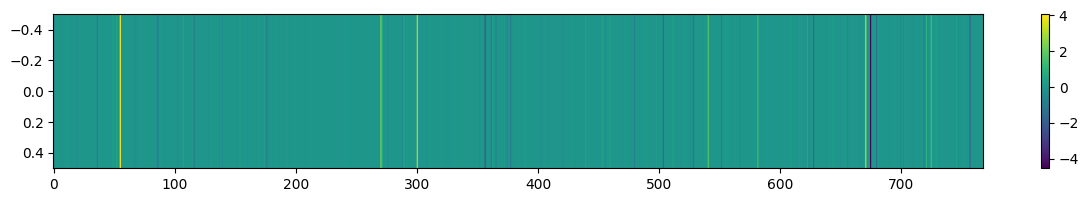

In [41]:
plt.figure(figsize=(15, 2))   # wider figure
plt.imshow(sd_hf["transformer.wpe.weight"][[0],:], aspect='auto')
plt.colorbar()
plt.show()

In [43]:
generator = pipeline("text-generation", model="gpt2")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2466.22it/s, Materializing param=transformer.wte.weight]             


In [45]:
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, and my project is based on the idea of a language model.\n\nI want to have a language that's both expressive and readable.\n\nLet's look at the following code:\n\nimport Data.ByteString\n\ndef get ( self ):\n\nself.data = Data.ByteString(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data"},
 {'generated_text': "Hello, I'm a language model, not a language model, and if I don't understand it, I won't learn to write it. So I was writing a system for programming in JavaScript and a s

In [ ]:
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

prompt = "The future of artificial intelligence is"

inputs = tokenizer(prompt, return_tensors="pt")#.to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        top_k=50,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(generated_text)


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2744.50it/s, Materializing param=transformer.wte.weight]             


The future of artificial intelligence is uncertain, but a new report by the International Monetary Fund (IMF) and its successor think tank says that AI could be poised to replace us all. The IMF's "AI Future" project – which was launched in 2013 as part-funded by


In [2]:
import tiktoken

In [3]:
enc = tiktoken.get_encoding("gpt2")

In [4]:
text = "What is going in here bruh?"

In [5]:
tokens = enc.encode(text)

In [6]:
tokens

[2061, 318, 1016, 287, 994, 18145, 71, 30]

In [ ]:
torch.tensor(1).size()

torch.Size([])